# Level 3 rotation analysis

This notebook is an exploratory analysis of level 3 accuracy by figure rotation angle.

It runs off the `.eval` log files produced by running the inspect evaluation (see the README's "Run Evaluation" section). Update the path in the first cell to point at your own eval log before running - the log used here (`../logs/level_3_test_2.eval`) is not distributed with the repository.

In [1]:
from inspect_ai.log import read_eval_log


log = read_eval_log("../logs/level_3_test_2.eval")

In [2]:
level_3_visual_samples = []
level_3_spatial_samples = []


assert log.samples is not None
for sample in log.samples:
    if sample.metadata["stimulus_set"] == "level_3" and sample.metadata["question_type"] == "visual":
        level_3_visual_samples.append(sample)
    elif sample.metadata["stimulus_set"] == "level_3" and sample.metadata["question_type"] == "spatial":
        level_3_spatial_samples.append(sample)

In [5]:
from collections import defaultdict

from inspect_ai.log import EvalSample

def calculate_accuracy(samples: list[EvalSample]):
    total = len(samples)
    if total == 0:
        return 0
    num_correct = 0
    for sample in samples:
        assert sample.scores is not None
        if sample.scores["simple_accuracy_scorer"].value == "C":
            num_correct += 1

    return num_correct/total

def calculate_accuracy_by_rotation(samples: list[EvalSample], round_to_degrees=10):
    """Calculate accuracy grouped by figure rotation angle"""
    rotation_groups = defaultdict(list)
    
    # Group samples by rounded rotation angle
    for sample in samples:
        original_rotation = sample.metadata["stimulus_metadata"]["figure_rotation"]
        # Round to nearest specified degrees (5 or 10)
        rounded_rotation = round(original_rotation / round_to_degrees) * round_to_degrees
        rotation_groups[rounded_rotation].append(sample)
    
    # Calculate accuracy for each rotation
    rotation_accuracies = {}
    for rotation, group_samples in rotation_groups.items():
        rotation_accuracies[rotation] = calculate_accuracy(group_samples)
    
    return rotation_accuracies

# Calculate accuracy by rotation for each category (rounded to nearest 10 degrees)
categories = {
    "Level 3 Visual": level_3_visual_samples,
    "Level 3 Spatial": level_3_spatial_samples
}

rotation_data = {}
for category_name, samples in categories.items():
    rotation_data[category_name] = calculate_accuracy_by_rotation(samples, round_to_degrees=20)

# Print summary of available rotations for each category
print("Available rotations by category (rounded to nearest 10°):")
for category, data in rotation_data.items():
    rotations = sorted(data.keys())
    print(f"{category}: {rotations}")
    print(f"  Sample data: {[(rot, f'{acc:.3f}') for rot, acc in sorted(data.items())]}")
    print()

Available rotations by category (rounded to nearest 10°):
Level 3 Visual: [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360]
  Sample data: [(0, '0.333'), (20, '0.250'), (40, '0.600'), (60, '0.875'), (80, '0.800'), (100, '0.250'), (120, '1.000'), (140, '1.000'), (160, '0.333'), (180, '0.500'), (200, '0.000'), (220, '0.000'), (240, '0.000'), (260, '0.000'), (280, '0.333'), (300, '0.000'), (320, '0.222'), (340, '0.222'), (360, '0.167')]

Level 3 Spatial: [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360]
  Sample data: [(0, '0.667'), (20, '0.250'), (40, '1.000'), (60, '0.875'), (80, '0.800'), (100, '0.750'), (120, '1.000'), (140, '0.667'), (160, '0.556'), (180, '1.000'), (200, '0.400'), (220, '0.500'), (240, '0.143'), (260, '0.000'), (280, '0.000'), (300, '0.400'), (320, '0.444'), (340, '0.333'), (360, '0.333')]



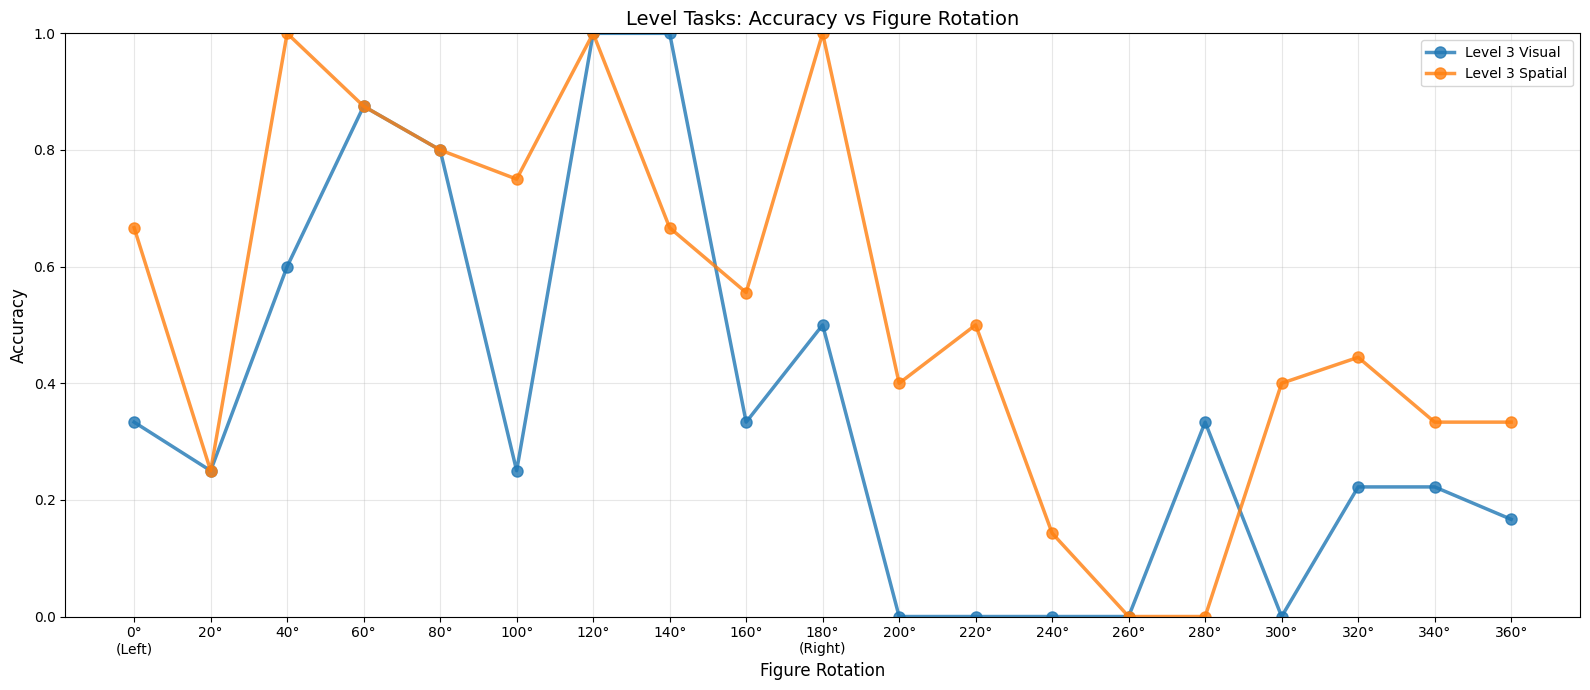


Control Tasks Summary:

Level Tasks Summary:
  Level 3 Visual: Mean=0.362, Std=0.333, Range=0.000-1.000
  Level 3 Spatial: Mean=0.533, Std=0.312, Range=0.000-1.000

Rotation angles tested: [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360]


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Get all unique rotation angles across all categories
all_rotations = set()
for data in rotation_data.values():
    all_rotations.update(data.keys())
all_rotations = sorted(all_rotations)

# Separate control and level categories
control_categories = {k: v for k, v in rotation_data.items() if k.startswith('Control')}
level_categories = {k: v for k, v in rotation_data.items() if k.startswith('Level')}

# Define colors for each category
colors = {
    'Level 3 Visual': '#1f77b4',    # blue
    'Level 3 Spatial': '#ff7f0e',   # orange
}

# Create rotation labels with directions
rotation_labels = []
direction_map = {0: 'Left', 90: 'Top', 180: 'Right', 270: 'Bottom'}
for rot in all_rotations:
    direction = direction_map.get(rot, '')
    if direction:
        rotation_labels.append(f'{int(rot)}°\n({direction})')
    else:
        rotation_labels.append(f'{int(rot)}°')

# Create subplots
fig, (ax2) = plt.subplots(1, 1, figsize=(16, 7))

# Function to plot categories
def plot_categories(ax, categories_dict, title):
    for category_name, data in categories_dict.items():
        # Extract rotations and accuracies for this category
        rotations = []
        accuracies = []
        for rotation in all_rotations:
            if rotation in data:
                rotations.append(rotation)
                accuracies.append(data[rotation])
        
        # Plot the line
        ax.plot(rotations, accuracies, 
               color=colors[category_name], linewidth=2.5, 
               marker='o', markersize=8,
               label=category_name, alpha=0.8)
    
    # Customize the plot
    ax.set_xlabel('Figure Rotation', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    # Set x-axis ticks with directional labels
    ax.set_xticks(all_rotations)
    ax.set_xticklabels(rotation_labels, fontsize=10)

# Plot level categories  
plot_categories(ax2, level_categories, 'Level Tasks: Accuracy vs Figure Rotation')

plt.tight_layout()
plt.show()

# Print summary statistics for each group
print("\nControl Tasks Summary:")
for category_name, data in control_categories.items():
    if data:
        accuracies = list(data.values())
        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        print(f"  {category_name}: Mean={mean_acc:.3f}, Std={std_acc:.3f}, Range={min(accuracies):.3f}-{max(accuracies):.3f}")

print("\nLevel Tasks Summary:")
for category_name, data in level_categories.items():
    if data:
        accuracies = list(data.values())
        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        print(f"  {category_name}: Mean={mean_acc:.3f}, Std={std_acc:.3f}, Range={min(accuracies):.3f}-{max(accuracies):.3f}")

print(f"\nRotation angles tested: {[int(rot) for rot in all_rotations]}")